# 🎓 Simulasi Pengambilan Keputusan Pemilihan Jurusan Kuliah
## Agent-Based Modeling (ABM) — Python & Mesa

**Nama Mahasiswa:** *(Isi Nama Anda)*  
**NIM:** *(Isi NIM Anda)*  
**Mata Kuliah:** Pemodelan dan Simulasi  
**Dosen:** *(Isi Nama Dosen)*  

---

### 📋 Deskripsi Project
Project ini mensimulasikan proses pengambilan keputusan pemilihan jurusan kuliah menggunakan
**Agent-Based Modeling (ABM)**. Setiap agen merepresentasikan calon mahasiswa dengan atribut:
- **M** = Minat (0–1)
- **K** = Kemampuan Akademik (0–1)
- **Sos** = Pengaruh Sosial (0–1)
- **C** = Tingkat Kebingungan (0–1)

### 🗺️ Struktur Notebook
| Bagian | Konten |
|--------|--------|
| **Bagian 1** | Coding Base Model — Agen bergerak & berinteraksi |
| **Bagian 2** | UTS Demo — Agen merespons stressor, grafik kenaikan C |
| **Bagian 3** | Implementasi Koping (CBT) — 5 teknik konseling |
| **Bagian 4** | Monte Carlo 1000 iterasi — Uji skenario What-If |

In [ ]:
# Install library yang dibutuhkan
# Mesa versi 1.2.1 digunakan karena kompatibel dengan RandomActivation
!pip install mesa==1.2.1 matplotlib numpy pandas seaborn --quiet
print('✓ Instalasi selesai')

✓ Instalasi selesai


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import random, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from mesa import Agent, Model
from mesa.time import RandomActivation
from mesa.space import MultiGrid
from mesa.datacollection import DataCollector

# ── Konfigurasi Global Plot ──────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'lines.linewidth': 2.2,
})

COLORS = {
    'yakin':   '#27AE60',
    'ragu':    '#F39C12',
    'salah':   '#E74C3C',
    'bingung': '#8E44AD',
    'stressor':'#C0392B',
    'cbt':     '#2980B9',
    'info':    '#16A085',
    'sosial':  '#D35400',
}

print('=' * 60)
print('  SIMULASI ABM — PEMILIHAN JURUSAN KULIAH')
print('=' * 60)
print('✓ Library loaded  |  Mesa v1.2.1')

  SIMULASI ABM — PEMILIHAN JURUSAN KULIAH
✓ Library loaded  |  Mesa v1.2.1


---
## 📦 BAGIAN 1: Coding Base Model
Membuat dunia simulasi dengan **agen bergerak dan berinteraksi** di lingkungan grid.

### Komponen Model:
- **`StudentAgent`** — Calon mahasiswa dengan atribut internal & mekanisme keputusan
- **`MajorSelectionModel`** — Environment grid 10×10, scheduler `RandomActivation`

### Formulasi Matematika:
| Rumus | Keterangan |
|-------|------------|
| `C(t+1) = C(t) + S + (Sos×0.3) − (I×0.4) − (CBT×0.5)` | Update kebingungan |
| `Score = (M×0.5) + (K×0.3) + (P×0.2)` | Skor kecocokan jurusan |

In [ ]:
# ╔══════════════════════════════════════════════════════╗
# ║        CLASS: StudentAgent                          ║
# ╚══════════════════════════════════════════════════════╝

class StudentAgent(Agent):
    """
    Agen merepresentasikan calon mahasiswa.
    Bergerak di grid, berinteraksi dengan agen lain,
    dan membuat keputusan pemilihan jurusan.
    """

    def __init__(self, unique_id, model,
                 minat=None, kemampuan=None,
                 sosial=None, kebingungan=None):
        super().__init__(unique_id, model)

        # ── Atribut Internal (skala 0–1) ─────────────────────
        self.M   = minat      if minat      is not None else random.uniform(0.3, 1.0)
        self.K   = kemampuan  if kemampuan  is not None else random.uniform(0.3, 1.0)
        self.Sos = sosial     if sosial     is not None else random.uniform(0.1, 0.7)
        self.C   = kebingungan if kebingungan is not None else random.uniform(0.4, 0.9)

        # ── Riwayat (untuk visualisasi) ──────────────────────
        self.history_C     = [self.C]
        self.history_score = []
        self.history_state = []

        # ── State Awal ────────────────────────────────────────
        self.state           = 'Bingung'
        self.jurusan_dipilih = None
        self.step_count      = 0

    # ── Hitung Skor Kecocokan Jurusan ────────────────────────
    def hitung_score(self):
        """Score = (M×0.5) + (K×0.3) + (P×0.2)"""
        P     = self.model.prospect
        score = (self.M * 0.5) + (self.K * 0.3) + (P * 0.2)
        return round(min(max(score, 0.0), 1.0), 4)

    # ── Update Kebingungan ────────────────────────────────────
    def update_kebingungan(self):
        """C(t+1) = C(t) + S + (Sos×0.3) − (I×0.4) − (CBT×0.5)"""
        S   = self.model.stressor
        I   = self.model.information
        CBT = self.model.cbt
        delta = S + (self.Sos * 0.3) - (I * 0.4) - (CBT * 0.5)
        self.C = round(min(max(self.C + delta * 0.15, 0.0), 1.0), 4)

    # ── Logika Keputusan ──────────────────────────────────────
    def ambil_keputusan(self):
        """Tentukan state berdasarkan score dan tingkat kebingungan."""
        score = self.hitung_score()
        if score >= 0.7 and self.C <= 0.3:
            self.state = 'Yakin'
            if self.jurusan_dipilih is None:
                self.jurusan_dipilih = self._pilih_jurusan()
        elif score >= 0.7 and self.C > 0.3:
            self.state = 'Ragu'
        else:
            self.state = 'Salah'
        return score

    def _pilih_jurusan(self):
        options = ['Teknik Informatika','Psikologi','Kedokteran',
                   'Manajemen','Teknik Sipil','Hukum','Ekonomi']
        return random.choice(options)

    # ── Interaksi Sosial antar Agen ───────────────────────────
    def interaksi_sosial(self):
        """Agen terpengaruh kondisi kebingungan tetangganya."""
        neighbors = self.model.grid.get_neighbors(
            self.pos, moore=True, include_center=False)
        if not neighbors:
            return
        # Pengaruh positif: agen yakin menurunkan kebingungan sekitar
        yakin_neighbors = [a for a in neighbors if a.state == 'Yakin']
        if yakin_neighbors:
            self.C = max(0.0, self.C - 0.02 * len(yakin_neighbors))
        # Pengaruh negatif: agen salah meningkatkan kebingungan sekitar
        salah_neighbors = [a for a in neighbors if a.state == 'Salah']
        if salah_neighbors:
            self.C = min(1.0, self.C + 0.01 * len(salah_neighbors))

    # ── Gerakan Acak di Grid ──────────────────────────────────
    def move(self):
        possible_steps = self.model.grid.get_neighborhood(
            self.pos, moore=True, include_center=False)
        new_pos = random.choice(possible_steps)
        self.model.grid.move_agent(self, new_pos)

    # ── Step Utama ────────────────────────────────────────────
    def step(self):
        self.step_count += 1
        self.move()               # 1. Bergerak
        self.interaksi_sosial()   # 2. Berinteraksi
        self.update_kebingungan() # 3. Update C
        score = self.ambil_keputusan()  # 4. Ambil keputusan
        self.history_C.append(self.C)
        self.history_score.append(score)
        self.history_state.append(self.state)

print('✓ StudentAgent class berhasil dibuat')

✓ StudentAgent class berhasil dibuat


In [ ]:
# ╔══════════════════════════════════════════════════════╗
# ║        CLASS: MajorSelectionModel                   ║
# ╚══════════════════════════════════════════════════════╝

class MajorSelectionModel(Model):
    """
    Environment simulasi pemilihan jurusan.
    Grid 10×10, 30 agen, variabel environment yang dapat dikontrol.
    """
    def __init__(self,
                 n_agents=30,
                 width=10, height=10,
                 information=0.5,   # I : akses informasi jurusan
                 prospect=0.6,      # P : prospek karier
                 stressor=0.3,      # S : tekanan/stres eksternal
                 cbt=0.4,           # CBT : dukungan konseling
                 seed=None):
        super().__init__()
        if seed is not None:
            random.seed(seed); np.random.seed(seed)

        self.num_agents  = n_agents
        self.grid        = MultiGrid(width, height, torus=True)
        self.schedule    = RandomActivation(self)

        # ── Variabel Environment ──────────────────────────────
        self.information = information
        self.prospect    = prospect
        self.stressor    = stressor
        self.cbt         = cbt

        # ── DataCollector ─────────────────────────────────────
        self.datacollector = DataCollector(
            model_reporters={
                'Avg_C':   lambda m: round(np.mean([a.C for a in m.schedule.agents]), 4),
                'N_Yakin': lambda m: sum(1 for a in m.schedule.agents if a.state == 'Yakin'),
                'N_Ragu':  lambda m: sum(1 for a in m.schedule.agents if a.state == 'Ragu'),
                'N_Salah': lambda m: sum(1 for a in m.schedule.agents if a.state == 'Salah'),
            },
            agent_reporters={
                'C':     'C',
                'State': 'state',
                'Score': lambda a: a.hitung_score(),
            }
        )

        # ── Buat & Tempatkan Agen ─────────────────────────────
        for i in range(n_agents):
            agent = StudentAgent(i, self)
            x = random.randrange(width)
            y = random.randrange(height)
            self.grid.place_agent(agent, (x, y))
            self.schedule.add(agent)

        self.datacollector.collect(self)

    def step(self):
        self.schedule.step()
        self.datacollector.collect(self)

    def run(self, n_steps):
        for _ in range(n_steps):
            self.step()

    def get_state_distribution(self):
        states = [a.state for a in self.schedule.agents]
        return {
            'Yakin':   states.count('Yakin'),
            'Ragu':    states.count('Ragu'),
            'Salah':   states.count('Salah'),
            'Bingung': states.count('Bingung'),
        }

print('✓ MajorSelectionModel class berhasil dibuat')

✓ MajorSelectionModel class berhasil dibuat


In [ ]:
# ── Jalankan Simulasi Base ───────────────────────────────────
N_STEPS_BASE = 50

model_base = MajorSelectionModel(
    n_agents=30, width=10, height=10,
    information=0.5, prospect=0.6,
    stressor=0.3, cbt=0.4, seed=42
)
model_base.run(N_STEPS_BASE)

df_model  = model_base.datacollector.get_model_vars_dataframe()
df_agents = model_base.datacollector.get_agent_vars_dataframe()

print(f'Simulasi selesai: {N_STEPS_BASE} langkah, {model_base.num_agents} agen')
print(f'Distribusi State Akhir: {model_base.get_state_distribution()}')
print(f'Avg Kebingungan Akhir : {df_model["Avg_C"].iloc[-1]:.4f}')
df_model.tail()

Simulasi selesai: 50 langkah, 30 agen
Distribusi State Akhir: {'Yakin': 0, 'Ragu': 6, 'Salah': 24, 'Bingung': 0}
Avg Kebingungan Akhir : 0.9723


,Avg_C,N_Yakin,N_Ragu,N_Salah
46,0.9730,0,6,24
47,0.9733,0,6,24
48,0.9723,0,6,24
49,0.9725,0,6,24
50,0.9723,0,6,24


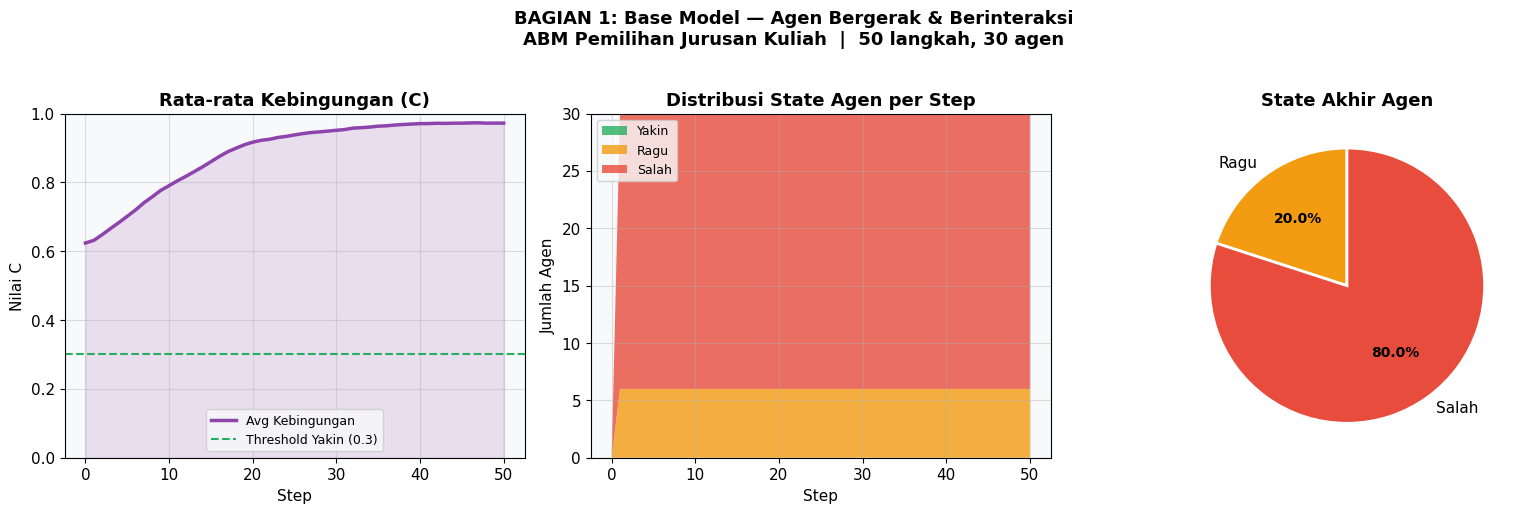

✓ fig1_base_model.png tersimpan


In [ ]:
# ── Visualisasi Base Model ───────────────────────────────────
fig1, axes = plt.subplots(1, 3, figsize=(16, 5))
fig1.suptitle(
    'BAGIAN 1: Base Model — Agen Bergerak & Berinteraksi\n'
    'ABM Pemilihan Jurusan Kuliah  |  50 langkah, 30 agen',
    fontsize=13, fontweight='bold', y=1.02
)

# Plot A: Rata-rata Kebingungan
ax = axes[0]
ax.plot(df_model.index, df_model['Avg_C'],
        color=COLORS['bingung'], linewidth=2.5, label='Avg Kebingungan')
ax.fill_between(df_model.index, df_model['Avg_C'],
                alpha=0.15, color=COLORS['bingung'])
ax.axhline(0.3, color=COLORS['yakin'], linestyle='--', linewidth=1.5,
           label='Threshold Yakin (0.3)')
ax.set_title('Rata-rata Kebingungan (C)'); ax.set_xlabel('Step')
ax.set_ylabel('Nilai C'); ax.set_ylim(0, 1); ax.legend(fontsize=9)

# Plot B: Distribusi State per Step
ax = axes[1]
ax.stackplot(
    df_model.index,
    df_model['N_Yakin'], df_model['N_Ragu'], df_model['N_Salah'],
    labels=['Yakin','Ragu','Salah'],
    colors=[COLORS['yakin'], COLORS['ragu'], COLORS['salah']],
    alpha=0.8
)
ax.set_title('Distribusi State Agen per Step'); ax.set_xlabel('Step')
ax.set_ylabel('Jumlah Agen'); ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, model_base.num_agents)

# Plot C: Pie State Akhir
ax = axes[2]
dist = model_base.get_state_distribution()
dist_nz = {k: v for k, v in dist.items() if v > 0}
clrs_pie = [COLORS.get(k.lower(), '#999') for k in dist_nz]
weds, txts, autos = ax.pie(
    dist_nz.values(), labels=dist_nz.keys(),
    autopct='%1.1f%%', colors=clrs_pie, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autos:
    at.set_fontsize(10); at.set_fontweight('bold')
ax.set_title('State Akhir Agen')

plt.tight_layout()
plt.savefig('fig1_base_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig1_base_model.png tersimpan')

---
## 📊 BAGIAN 2: UTS Demo — Agen Merespons Stressor
Menunjukkan bagaimana **tingkat stressor yang berbeda** mempengaruhi
kenaikan kebingungan (C) agen dan berapa banyak yang salah pilih jurusan.

| Kondisi | Stressor | Ekspektasi |
|---------|----------|------------|
| Rendah | 0.1 | C stabil / turun |
| Sedang | 0.3 | C naik perlahan |
| Tinggi | 0.5 | C naik cepat |
| Ekstrem | 0.8 | C maksimum, banyak salah |

In [ ]:
# ── UTS Demo: Jalankan 4 Level Stressor ─────────────────────

N_STEPS_UTS = 60
stressor_configs = [
    (0.1, 'Stressor Rendah (0.1)'),
    (0.3, 'Stressor Sedang (0.3)'),
    (0.5, 'Stressor Tinggi (0.5)'),
    (0.8, 'Stressor Ekstrem (0.8)'),
]
line_colors = ['#27AE60','#F39C12','#E67E22','#C0392B']

results_uts = {}
print('Menjalankan simulasi UTS...\n')
for s_val, s_label in stressor_configs:
    m = MajorSelectionModel(
        n_agents=30, stressor=s_val,
        information=0.4, cbt=0.2, seed=42)
    m.run(N_STEPS_UTS)
    df = m.datacollector.get_model_vars_dataframe()
    dist = m.get_state_distribution()
    results_uts[s_label] = {'df': df, 'model': m}
    print(f'  {s_label:30s} → Avg C: {df["Avg_C"].iloc[-1]:.3f}'
          f'  | Yakin: {dist["Yakin"]:2d}  Salah: {dist["Salah"]:2d}')

print('\n✓ Simulasi UTS selesai')

Menjalankan simulasi UTS...

  Stressor Rendah (0.1)          → Avg C: 0.868  | Yakin:  0  Salah: 24


  Stressor Sedang (0.3)          → Avg C: 1.000  | Yakin:  0  Salah: 24
  Stressor Tinggi (0.5)          → Avg C: 1.000  | Yakin:  0  Salah: 24


  Stressor Ekstrem (0.8)         → Avg C: 1.000  | Yakin:  0  Salah: 24

✓ Simulasi UTS selesai


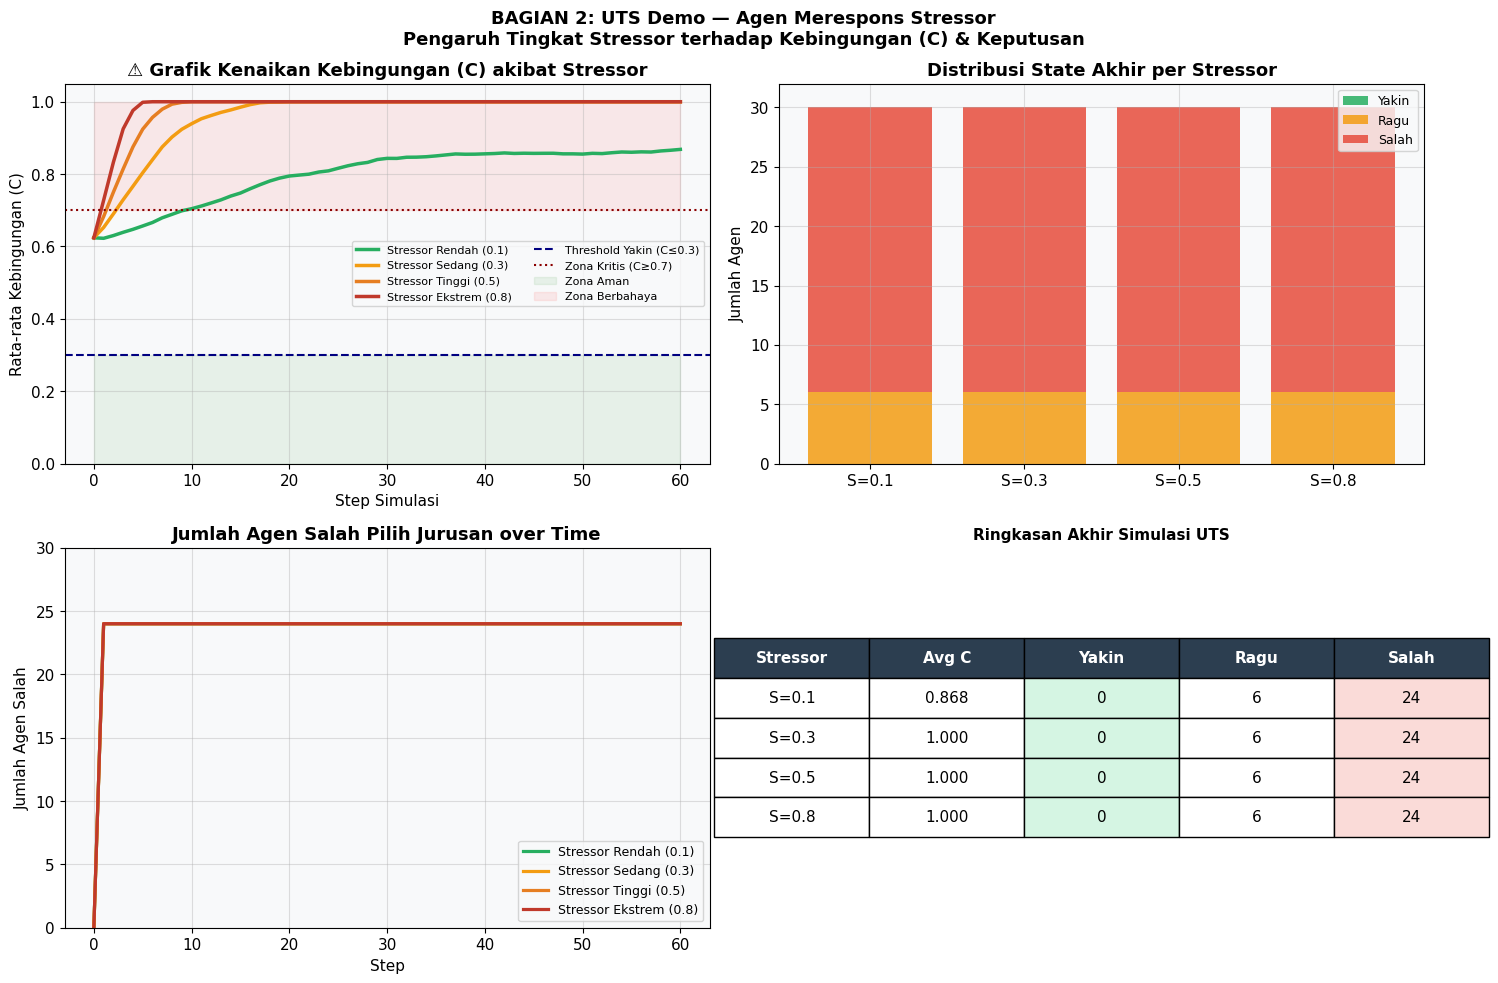

✓ fig2_uts_demo.png tersimpan


In [ ]:
# ── Visualisasi UTS ──────────────────────────────────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(15, 10))
fig2.suptitle(
    'BAGIAN 2: UTS Demo — Agen Merespons Stressor\n'
    'Pengaruh Tingkat Stressor terhadap Kebingungan (C) & Keputusan',
    fontsize=13, fontweight='bold'
)

# Plot A: Grafik kenaikan C per stressor (utama)
ax = axes2[0, 0]
for (s_val, s_label), lc in zip(stressor_configs, line_colors):
    df = results_uts[s_label]['df']
    ax.plot(df.index, df['Avg_C'], color=lc, linewidth=2.5, label=s_label)
ax.axhline(0.3, color='navy', linestyle='--', linewidth=1.5,
           label='Threshold Yakin (C≤0.3)')
ax.axhline(0.7, color='darkred', linestyle=':', linewidth=1.5,
           label='Zona Kritis (C≥0.7)')
ax.fill_between(range(N_STEPS_UTS+1), 0, 0.3,
                alpha=0.07, color='green', label='Zona Aman')
ax.fill_between(range(N_STEPS_UTS+1), 0.7, 1.0,
                alpha=0.07, color='red', label='Zona Berbahaya')
ax.set_title('⚠ Grafik Kenaikan Kebingungan (C) akibat Stressor')
ax.set_xlabel('Step Simulasi'); ax.set_ylabel('Rata-rata Kebingungan (C)')
ax.set_ylim(0, 1.05); ax.legend(fontsize=8, ncol=2)

# Plot B: Distribusi State Akhir — stacked bar
ax = axes2[0, 1]
labels_b = [f'S={s:.1f}' for s, _ in stressor_configs]
yakin_v = [results_uts[l]['model'].get_state_distribution()['Yakin'] for _, l in stressor_configs]
ragu_v  = [results_uts[l]['model'].get_state_distribution()['Ragu']  for _, l in stressor_configs]
salah_v = [results_uts[l]['model'].get_state_distribution()['Salah'] for _, l in stressor_configs]
x_b = np.arange(len(labels_b))
ax.bar(x_b, yakin_v, label='Yakin', color=COLORS['yakin'], alpha=0.85)
ax.bar(x_b, ragu_v,  bottom=yakin_v, label='Ragu',  color=COLORS['ragu'],  alpha=0.85)
bot = [y+r for y,r in zip(yakin_v, ragu_v)]
ax.bar(x_b, salah_v, bottom=bot,    label='Salah', color=COLORS['salah'], alpha=0.85)
ax.set_xticks(x_b); ax.set_xticklabels(labels_b)
ax.set_title('Distribusi State Akhir per Stressor')
ax.set_ylabel('Jumlah Agen'); ax.set_ylim(0, 32); ax.legend(fontsize=9)

# Plot C: N_Salah over time
ax = axes2[1, 0]
for (s_val, s_label), lc in zip(stressor_configs, line_colors):
    df = results_uts[s_label]['df']
    ax.plot(df.index, df['N_Salah'], color=lc, linewidth=2.3, label=s_label)
ax.set_title('Jumlah Agen Salah Pilih Jurusan over Time')
ax.set_xlabel('Step'); ax.set_ylabel('Jumlah Agen Salah')
ax.set_ylim(0, 30); ax.legend(fontsize=9)

# Plot D: Tabel ringkasan
ax = axes2[1, 1]; ax.axis('off')
tdata = []
for s_val, s_label in stressor_configs:
    dist  = results_uts[s_label]['model'].get_state_distribution()
    avg_c = results_uts[s_label]['df']['Avg_C'].iloc[-1]
    tdata.append([f'S={s_val}', f'{avg_c:.3f}',
                   str(dist['Yakin']), str(dist['Ragu']), str(dist['Salah'])])
tbl = ax.table(cellText=tdata,
               colLabels=['Stressor','Avg C','Yakin','Ragu','Salah'],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.2, 2.2)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50'); cell.set_text_props(color='white', fontweight='bold')
    elif c == 2: cell.set_facecolor('#D5F5E3')
    elif c == 4: cell.set_facecolor('#FADBD8')
ax.set_title('Ringkasan Akhir Simulasi UTS', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_uts_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig2_uts_demo.png tersimpan')

---
## 🩺 BAGIAN 3: Implementasi Koping (CBT)
Menambahkan **5 teknik CBT** yang diadaptasi ke konteks akademik:

| Teknik CBT | Efektivitas | Kondisi Ideal |
|------------|-------------|---------------|
| Konseling Akademik | 0.55 (tertinggi) | C > 0.7 (panik) |
| Tes Minat & Bakat  | 0.50 | C > 0.5 |
| Seminar Jurusan    | 0.40 | C > 0.35 |
| Guru BK            | 0.45 | C > 0.2 |
| Mentoring          | 0.35 | C rendah |

Agen memilih teknik secara **otomatis** sesuai tingkat kebingungannya.

In [ ]:
# ── StudentAgent dengan CBT ──────────────────────────────────

class StudentAgentCBT(StudentAgent):
    """
    Agen yang dilengkapi 5 teknik CBT akademik.
    Memilih teknik secara otomatis berdasarkan tingkat kebingungan.
    """
    CBT_TECHNIQUES = {
        'konseling_akademik': 0.55,  # Paling efektif, untuk kondisi kritis
        'tes_minat_bakat':    0.50,  # Efektif, clarify self-awareness
        'guru_BK':            0.45,  # Dukungan personal
        'seminar_jurusan':    0.40,  # Informasi jurusan
        'mentoring':          0.35,  # Peer support
    }

    def __init__(self, unique_id, model, **kwargs):
        super().__init__(unique_id, model, **kwargs)
        self.active_cbt  = None
        self.cbt_counter = 0
        self.cbt_log     = []

    def apply_cbt(self):
        """Pilih & terapkan teknik CBT sesuai kondisi agen."""
        # Pemilihan teknik adaptif berdasarkan tingkat kebingungan
        if   self.C > 0.7:  self.active_cbt = 'konseling_akademik'
        elif self.C > 0.5:  self.active_cbt = 'tes_minat_bakat'
        elif self.C > 0.35: self.active_cbt = 'seminar_jurusan'
        elif self.C > 0.2:  self.active_cbt = 'guru_BK'
        else:               self.active_cbt = 'mentoring'

        effect    = self.CBT_TECHNIQUES[self.active_cbt]
        reduction = effect * self.model.cbt * 0.12
        self.C    = round(max(0.0, self.C - reduction), 4)
        self.cbt_counter += 1
        self.cbt_log.append({'step': self.step_count, 'technique': self.active_cbt,
                             'effect': round(reduction, 4), 'C_after': self.C})

    def step(self):
        self.step_count += 1
        self.move()
        self.interaksi_sosial()
        self.update_kebingungan()
        if self.model.cbt > 0 and self.C > 0.2:  # Terapkan CBT jika tersedia
            self.apply_cbt()
        score = self.ambil_keputusan()
        self.history_C.append(self.C)
        self.history_score.append(score)
        self.history_state.append(self.state)


class MajorSelectionModelCBT(MajorSelectionModel):
    """Model dengan agen CBT dan DataCollector yang diperluas."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Reinisialisasi dengan agen CBT
        self.schedule = RandomActivation(self)
        self.grid     = MultiGrid(10, 10, torus=True)
        seed = kwargs.get('seed', None)
        if seed is not None:
            random.seed(seed); np.random.seed(seed)
        for i in range(self.num_agents):
            agent = StudentAgentCBT(i, self)
            x = random.randrange(10); y = random.randrange(10)
            self.grid.place_agent(agent, (x, y))
            self.schedule.add(agent)
        self.datacollector = DataCollector(
            model_reporters={
                'Avg_C':     lambda m: round(np.mean([a.C for a in m.schedule.agents]),4),
                'N_Yakin':   lambda m: sum(1 for a in m.schedule.agents if a.state=='Yakin'),
                'N_Ragu':    lambda m: sum(1 for a in m.schedule.agents if a.state=='Ragu'),
                'N_Salah':   lambda m: sum(1 for a in m.schedule.agents if a.state=='Salah'),
                'Avg_Score': lambda m: round(np.mean([a.hitung_score() for a in m.schedule.agents]),4),
                'CBT_Count': lambda m: sum(a.cbt_counter for a in m.schedule.agents),
            },
            agent_reporters={
                'C': 'C', 'State': 'state',
                'Score': lambda a: a.hitung_score(),
                'Active_CBT': 'active_cbt',
                'CBT_Count': 'cbt_counter',
            }
        )
        self.datacollector.collect(self)

print('✓ StudentAgentCBT & MajorSelectionModelCBT siap')

✓ StudentAgentCBT & MajorSelectionModelCBT siap


In [ ]:
# ── Jalankan Perbandingan 5 Kondisi CBT ──────────────────────
N_STEPS_CBT = 80

configs_cbt = [
    {'label': 'Tanpa CBT',        'cbt': 0.0, 'stressor': 0.5, 'information': 0.3},
    {'label': 'CBT Rendah',       'cbt': 0.3, 'stressor': 0.5, 'information': 0.4},
    {'label': 'CBT Sedang',       'cbt': 0.6, 'stressor': 0.5, 'information': 0.5},
    {'label': 'CBT Tinggi',       'cbt': 0.9, 'stressor': 0.5, 'information': 0.6},
    {'label': 'CBT+Info Optimal', 'cbt': 0.9, 'stressor': 0.2, 'information': 0.9},
]
cbt_colors = ['#C0392B','#E67E22','#F1C40F','#27AE60','#1ABC9C']

results_cbt = {}
print('Menjalankan simulasi CBT...\n')
for cfg in configs_cbt:
    m = MajorSelectionModelCBT(
        n_agents=30, information=cfg['information'],
        prospect=0.6, stressor=cfg['stressor'],
        cbt=cfg['cbt'], seed=42)
    m.run(N_STEPS_CBT)
    df  = m.datacollector.get_model_vars_dataframe()
    dist = m.get_state_distribution()
    results_cbt[cfg['label']] = {'df': df, 'model': m, 'cfg': cfg}
    print(f'  {cfg["label"]:25s} → Avg C: {df["Avg_C"].iloc[-1]:.3f}'
          f'  Yakin: {dist["Yakin"]:2d}  Salah: {dist["Salah"]:2d}')

print('\n✓ Simulasi CBT selesai')

Menjalankan simulasi CBT...

  Tanpa CBT                 → Avg C: 1.000  Yakin:  0  Salah: 24


  CBT Rendah                → Avg C: 0.980  Yakin:  0  Salah: 24


  CBT Sedang                → Avg C: 0.458  Yakin:  4  Salah: 24
  CBT Tinggi                → Avg C: 0.055  Yakin:  6  Salah: 24


  CBT+Info Optimal          → Avg C: 0.000  Yakin:  6  Salah: 24

✓ Simulasi CBT selesai


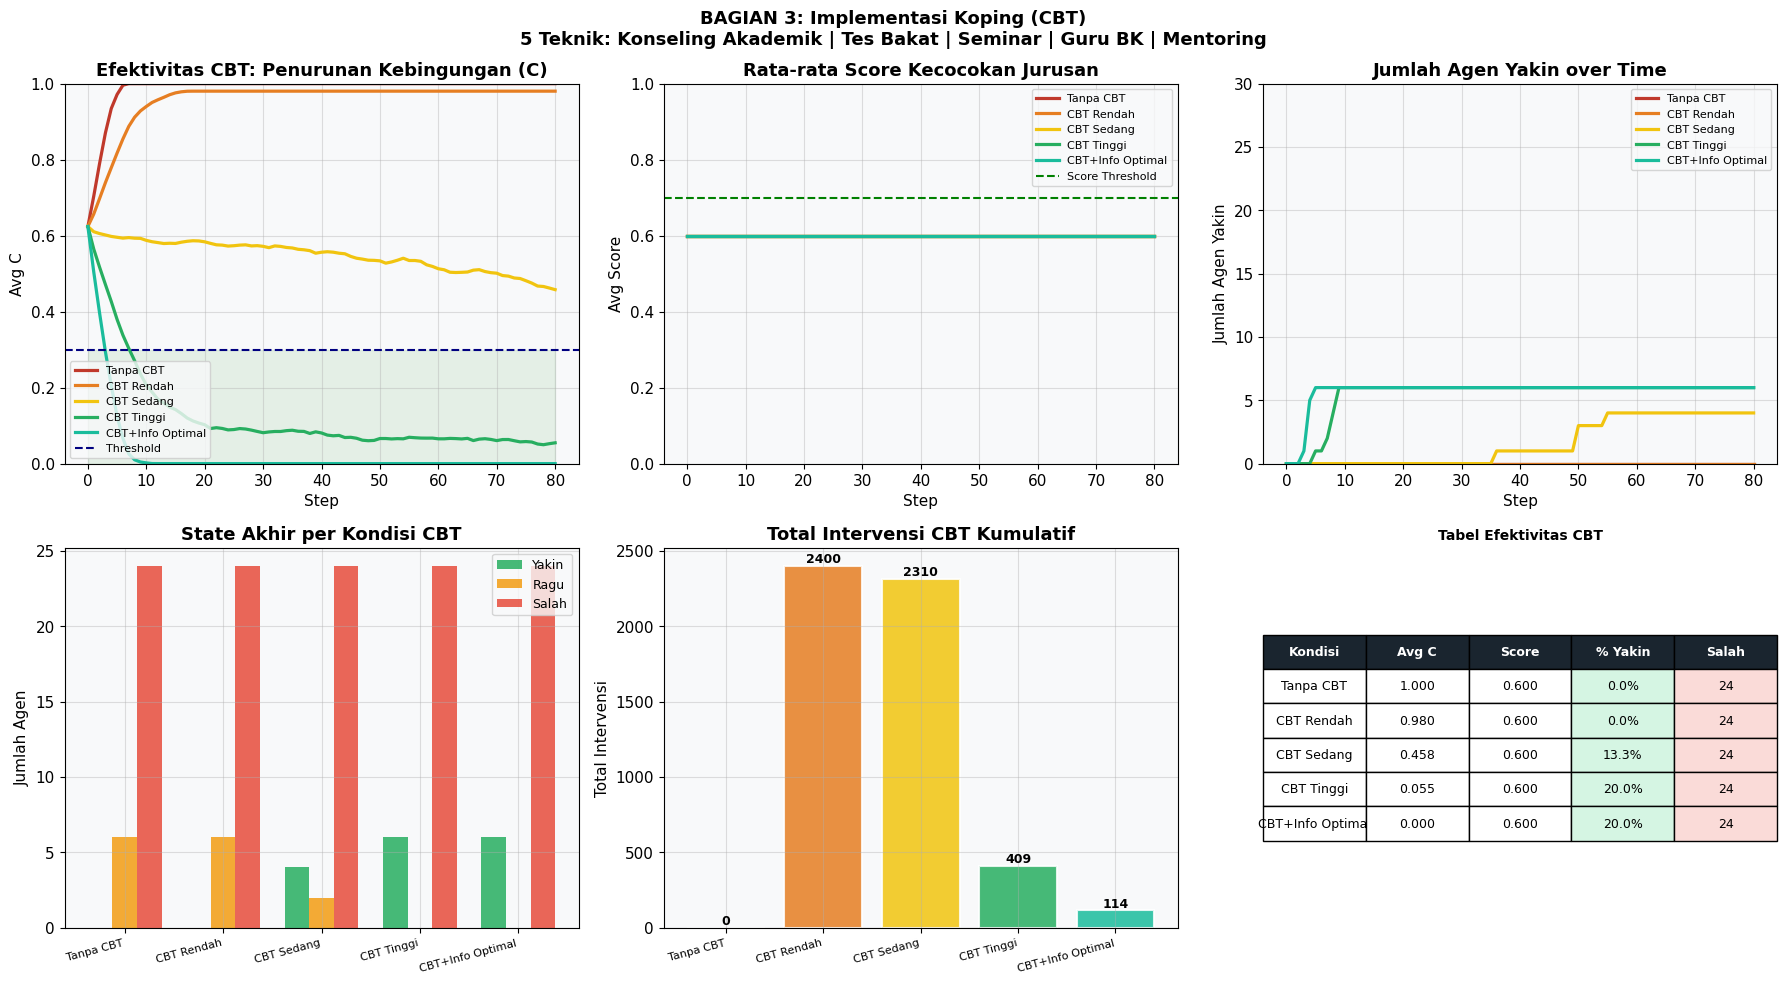

✓ fig3_cbt.png tersimpan


In [ ]:
# ── Visualisasi CBT ──────────────────────────────────────────
fig3, axes3 = plt.subplots(2, 3, figsize=(18, 10))
fig3.suptitle(
    'BAGIAN 3: Implementasi Koping (CBT)\n'
    '5 Teknik: Konseling Akademik | Tes Bakat | Seminar | Guru BK | Mentoring',
    fontsize=13, fontweight='bold'
)

# A: Kurva Avg C
ax = axes3[0, 0]
for (label, res), clr in zip(results_cbt.items(), cbt_colors):
    df = res['df']
    ax.plot(df.index, df['Avg_C'], color=clr, linewidth=2.3, label=label)
ax.axhline(0.3, color='navy', linestyle='--', linewidth=1.5, label='Threshold')
ax.fill_between(range(N_STEPS_CBT+1), 0, 0.3, alpha=0.08, color='green')
ax.set_title('Efektivitas CBT: Penurunan Kebingungan (C)')
ax.set_xlabel('Step'); ax.set_ylabel('Avg C'); ax.set_ylim(0,1); ax.legend(fontsize=8)

# B: Avg Score
ax = axes3[0, 1]
for (label, res), clr in zip(results_cbt.items(), cbt_colors):
    ax.plot(res['df'].index, res['df']['Avg_Score'], color=clr, linewidth=2.3, label=label)
ax.axhline(0.7, color='green', linestyle='--', linewidth=1.5, label='Score Threshold')
ax.set_title('Rata-rata Score Kecocokan Jurusan')
ax.set_xlabel('Step'); ax.set_ylabel('Avg Score'); ax.set_ylim(0,1); ax.legend(fontsize=8)

# C: N_Yakin over time
ax = axes3[0, 2]
for (label, res), clr in zip(results_cbt.items(), cbt_colors):
    ax.plot(res['df'].index, res['df']['N_Yakin'], color=clr, linewidth=2.3, label=label)
ax.set_title('Jumlah Agen Yakin over Time')
ax.set_xlabel('Step'); ax.set_ylabel('Jumlah Agen Yakin'); ax.set_ylim(0,30); ax.legend(fontsize=8)

# D: Grouped bar state akhir
ax = axes3[1, 0]
x_ = np.arange(len(configs_cbt)); w_ = 0.25
y_data = {'Yakin': [], 'Ragu': [], 'Salah': []}
for cfg in configs_cbt:
    dist = results_cbt[cfg['label']]['model'].get_state_distribution()
    for k in y_data: y_data[k].append(dist[k])
b1 = ax.bar(x_-w_, y_data['Yakin'], w_, label='Yakin', color=COLORS['yakin'], alpha=0.85)
b2 = ax.bar(x_,    y_data['Ragu'],  w_, label='Ragu',  color=COLORS['ragu'],  alpha=0.85)
b3 = ax.bar(x_+w_, y_data['Salah'], w_, label='Salah', color=COLORS['salah'], alpha=0.85)
ax.set_xticks(x_); ax.set_xticklabels([c['label'] for c in configs_cbt], rotation=15, ha='right', fontsize=8)
ax.set_title('State Akhir per Kondisi CBT'); ax.set_ylabel('Jumlah Agen'); ax.legend(fontsize=9)

# E: Total CBT interventions
ax = axes3[1, 1]
totals = [results_cbt[c['label']]['df']['CBT_Count'].iloc[-1] for c in configs_cbt]
bars = ax.bar([c['label'] for c in configs_cbt], totals, color=cbt_colors, alpha=0.85, edgecolor='white', lw=1.5)
for bar, val in zip(bars, totals):
    ax.text(bar.get_x()+bar.get_width()/2, val+3, f'{int(val)}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Total Intervensi CBT Kumulatif')
ax.set_ylabel('Total Intervensi')
ax.set_xticklabels([c['label'] for c in configs_cbt], rotation=15, ha='right', fontsize=8)

# F: Tabel ringkasan
ax = axes3[1, 2]; ax.axis('off')
rows = []
for cfg in configs_cbt:
    df  = results_cbt[cfg['label']]['df']
    dist = results_cbt[cfg['label']]['model'].get_state_distribution()
    rows.append([cfg['label'], f"{df['Avg_C'].iloc[-1]:.3f}",
                  f"{df['Avg_Score'].iloc[-1]:.3f}",
                  f"{dist['Yakin']/30*100:.1f}%", str(dist['Salah'])])
tbl = ax.table(cellText=rows, colLabels=['Kondisi','Avg C','Score','% Yakin','Salah'],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.9)
for (r,c), cell in tbl.get_celld().items():
    if r==0: cell.set_facecolor('#1A252F'); cell.set_text_props(color='white', fontweight='bold')
    elif c==3: cell.set_facecolor('#D5F5E3')
    elif c==4: cell.set_facecolor('#FADBD8')
ax.set_title('Tabel Efektivitas CBT', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_cbt.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig3_cbt.png tersimpan')

---
## 🎲 BAGIAN 4: Uji Skenario Monte Carlo (1000 Iterasi)
Menjalankan **1000 iterasi per skenario** untuk analisis statistik yang robust.

| Skenario | Kondisi | Hipotesis |
|----------|---------|----------|
| **1. Tanpa Intervensi** | Stressor=0.8, CBT=0, Info=0.2 | % Yakin mendekati 0% |
| **2. Pengaruh Sosial Tinggi** | Stressor=0.6, CBT=0.2, Info=0.2 | Banyak salah jurusan |
| **3. Akses Informasi Tinggi** | Stressor=0.2, CBT=0.8, Info=0.9 | % Yakin tertinggi |
| **4. Minat-Kemampuan Tidak Sesuai** | Prospek=0.2, Stressor=0.5 | Score rendah, banyak salah |

In [ ]:
# ── Definisi Skenario What-If ────────────────────────────────

SCENARIOS = {
    'Skenario 1: Tanpa Intervensi': {
        'description': 'Stressor tinggi, tidak ada CBT, informasi sangat rendah',
        'information': 0.2, 'stressor': 0.8, 'cbt': 0.0, 'prospect': 0.5,
        'color': '#C0392B'
    },
    'Skenario 2: Pengaruh Sosial Tinggi': {
        'description': 'Tekanan sosial dominan, informasi dan CBT rendah',
        'information': 0.2, 'stressor': 0.6, 'cbt': 0.2, 'prospect': 0.5,
        'color': '#E67E22'
    },
    'Skenario 3: Akses Informasi Tinggi': {
        'description': 'Informasi melimpah, CBT tinggi, stressor rendah',
        'information': 0.9, 'stressor': 0.2, 'cbt': 0.8, 'prospect': 0.7,
        'color': '#27AE60'
    },
    'Skenario 4: Minat-Kemampuan Tidak Sesuai': {
        'description': 'Prospek karier sangat rendah, mismatch minat-kemampuan',
        'information': 0.5, 'stressor': 0.5, 'cbt': 0.5, 'prospect': 0.2,
        'color': '#8E44AD'
    },
}

def run_single_simulation(params, n_steps=50, seed=None):
    """Jalankan 1 simulasi, return hasil akhir."""
    m = MajorSelectionModelCBT(
        n_agents=30,
        information=params['information'],
        prospect=params.get('prospect', 0.6),
        stressor=params['stressor'],
        cbt=params['cbt'],
        seed=seed
    )
    m.run(n_steps)
    df   = m.datacollector.get_model_vars_dataframe()
    dist = m.get_state_distribution()
    return {
        'yakin':     dist['Yakin'],
        'ragu':      dist['Ragu'],
        'salah':     dist['Salah'],
        'avg_C':     df['Avg_C'].iloc[-1],
        'avg_score': df['Avg_Score'].iloc[-1],
        'pct_yakin': dist['Yakin'] / 30 * 100,
        'pct_salah': dist['Salah'] / 30 * 100,
    }

print('✓ Skenario & fungsi Monte Carlo siap')
print(f'Total skenario: {len(SCENARIOS)}')

✓ Skenario & fungsi Monte Carlo siap
Total skenario: 4


In [ ]:
# ── Jalankan Monte Carlo 1000 Iterasi ────────────────────────
# ⏱ Estimasi waktu: 3–8 menit (tergantung runtime)

N_MC = 1000
N_SIM_STEPS = 50

print(f'Menjalankan {N_MC} iterasi per skenario...')
print(f'Total simulasi: {N_MC * len(SCENARIOS):,}\n')

mc_results = {}
for sc_name, sc_params in SCENARIOS.items():
    print(f'  → {sc_name}')
    runs = [run_single_simulation(sc_params, n_steps=N_SIM_STEPS, seed=i)
            for i in range(N_MC)]
    df_mc = pd.DataFrame(runs)
    mc_results[sc_name] = {'df': df_mc, 'params': sc_params}

    mean_c = df_mc['avg_C'].mean()
    std_c  = df_mc['avg_C'].std()
    ci95   = 1.96 * std_c / math.sqrt(N_MC)
    print(f'     Avg C    : {mean_c:.4f} ± {std_c:.4f}  (CI 95%: ±{ci95:.4f})')
    print(f'     % Yakin  : {df_mc["pct_yakin"].mean():.1f}%   '
          f'% Salah: {df_mc["pct_salah"].mean():.1f}%\n')

print('✓ Monte Carlo selesai!')

Menjalankan 1000 iterasi per skenario...
Total simulasi: 4,000

  → Skenario 1: Tanpa Intervensi


     Avg C    : 1.0000 ± 0.0000  (CI 95%: ±0.0000)
     % Yakin  : 0.0%   % Salah: 72.7%

  → Skenario 2: Pengaruh Sosial Tinggi


     Avg C    : 0.9868 ± 0.0000  (CI 95%: ±0.0000)
     % Yakin  : 0.0%   % Salah: 72.7%

  → Skenario 3: Akses Informasi Tinggi


     Avg C    : 0.0000 ± 0.0000  (CI 95%: ±0.0000)
     % Yakin  : 38.3%   % Salah: 61.7%

  → Skenario 4: Minat-Kemampuan Tidak Sesuai


     Avg C    : 0.9144 ± 0.0232  (CI 95%: ±0.0014)
     % Yakin  : 0.0%   % Salah: 86.5%

✓ Monte Carlo selesai!


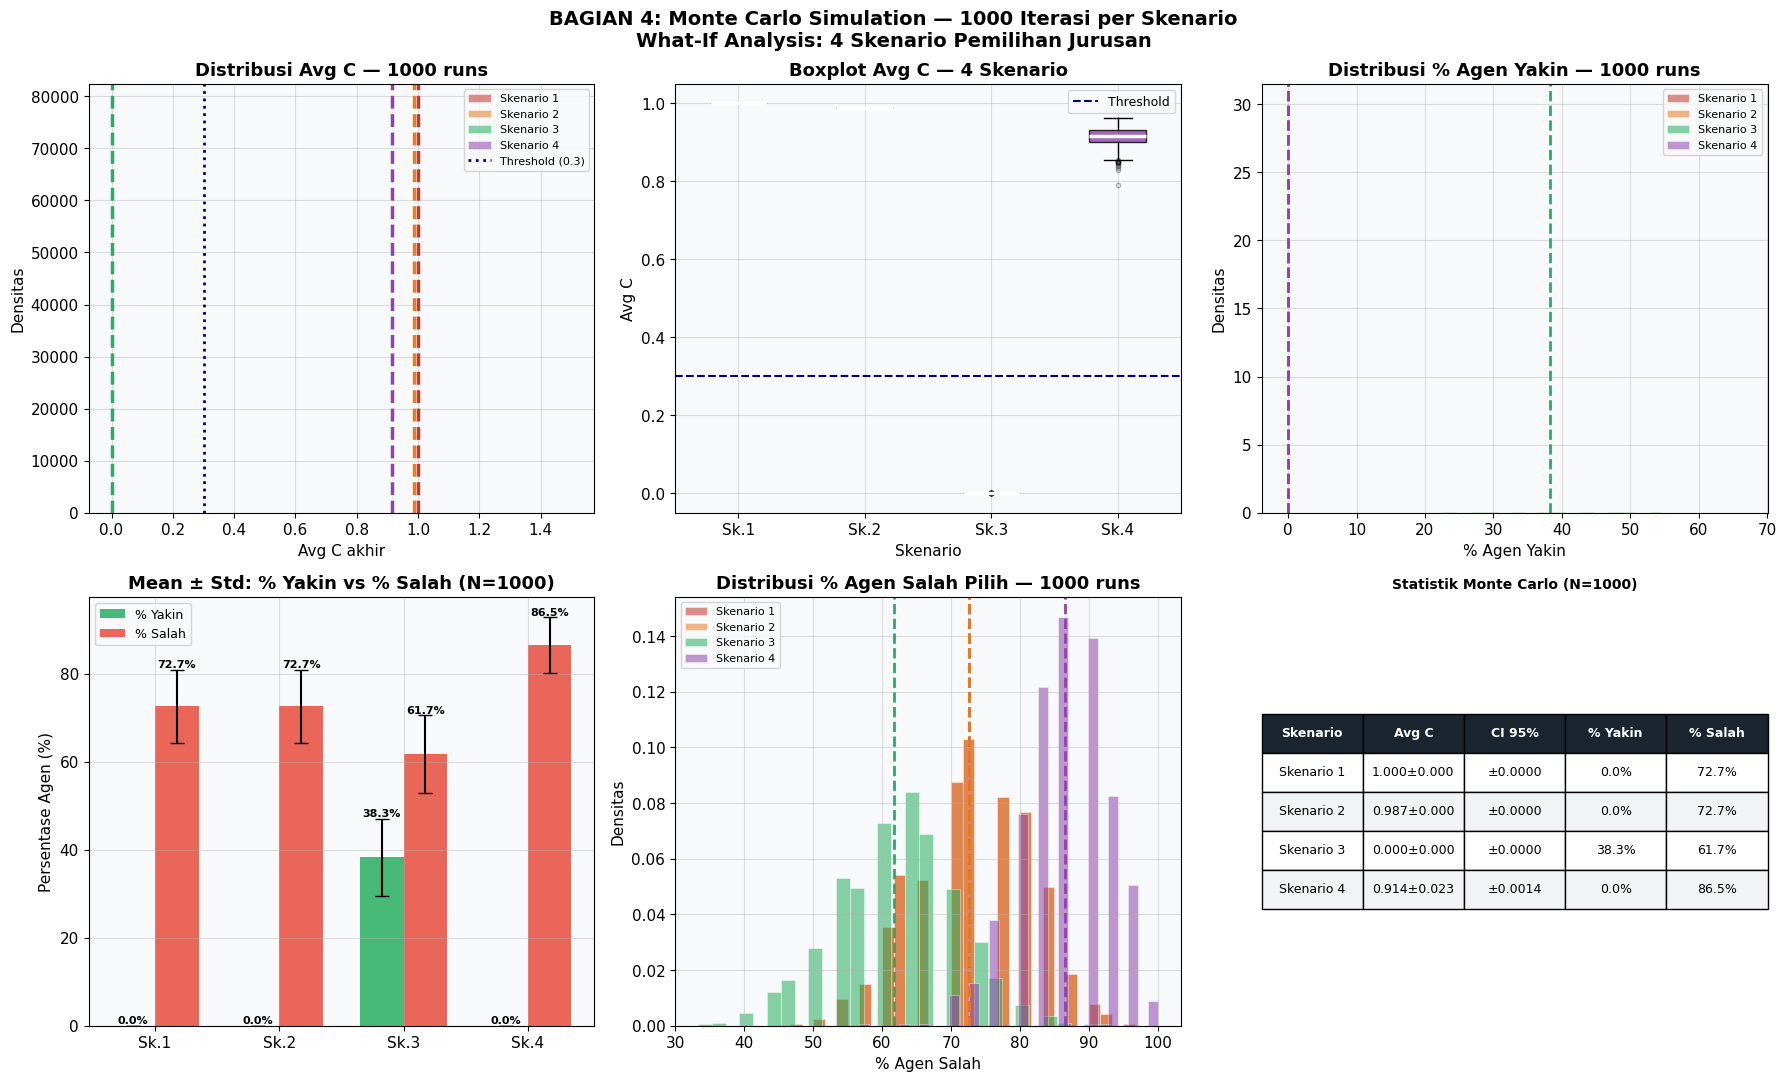

✓ fig4_monte_carlo.png tersimpan


In [ ]:
# ── Visualisasi Monte Carlo ───────────────────────────────────
sc_names  = list(mc_results.keys())
sc_colors = [SCENARIOS[n]['color'] for n in sc_names]
sc_short  = [f'Sk.{i+1}' for i in range(4)]

fig4, axes4 = plt.subplots(2, 3, figsize=(18, 11))
fig4.suptitle(
    'BAGIAN 4: Monte Carlo Simulation — 1000 Iterasi per Skenario\n'
    'What-If Analysis: 4 Skenario Pemilihan Jurusan',
    fontsize=14, fontweight='bold'
)

# A: Distribusi Avg C (histogram overlay)
ax = axes4[0, 0]
for name, clr in zip(sc_names, sc_colors):
    df_mc = mc_results[name]['df']
    ax.hist(df_mc['avg_C'], bins=40, alpha=0.55, color=clr,
            label=name.split(':')[0], density=True, edgecolor='white', linewidth=0.5)
    ax.axvline(df_mc['avg_C'].mean(), color=clr, linewidth=2.5, linestyle='--')
ax.axvline(0.3, color='navy', linewidth=2, linestyle=':', label='Threshold (0.3)')
ax.set_title('Distribusi Avg C — 1000 runs')
ax.set_xlabel('Avg C akhir'); ax.set_ylabel('Densitas'); ax.legend(fontsize=8)

# B: Boxplot Avg C
ax = axes4[0, 1]
data_box = [mc_results[n]['df']['avg_C'].values for n in sc_names]
bp = ax.boxplot(data_box, labels=sc_short, patch_artist=True,
                medianprops=dict(color='white', linewidth=2.5))
for patch, clr in zip(bp['boxes'], sc_colors):
    patch.set_facecolor(clr); patch.set_alpha(0.8)
for flier, clr in zip(bp['fliers'], sc_colors):
    flier.set(marker='o', color=clr, alpha=0.3, markersize=3)
ax.axhline(0.3, color='navy', linestyle='--', linewidth=1.5, label='Threshold')
ax.set_title('Boxplot Avg C — 4 Skenario')
ax.set_xlabel('Skenario'); ax.set_ylabel('Avg C'); ax.legend(fontsize=9)

# C: % Yakin per skenario (histogram overlay)
ax = axes4[0, 2]
for name, clr in zip(sc_names, sc_colors):
    df_mc = mc_results[name]['df']
    ax.hist(df_mc['pct_yakin'], bins=30, alpha=0.55, color=clr,
            label=name.split(':')[0], density=True, edgecolor='white', linewidth=0.5)
    ax.axvline(df_mc['pct_yakin'].mean(), color=clr, linewidth=2, linestyle='--')
ax.set_title('Distribusi % Agen Yakin — 1000 runs')
ax.set_xlabel('% Agen Yakin'); ax.set_ylabel('Densitas'); ax.legend(fontsize=8)

# D: Mean ± Std Yakin vs Salah
ax = axes4[1, 0]
means_y = [mc_results[n]['df']['pct_yakin'].mean() for n in sc_names]
stds_y  = [mc_results[n]['df']['pct_yakin'].std()  for n in sc_names]
means_s = [mc_results[n]['df']['pct_salah'].mean() for n in sc_names]
stds_s  = [mc_results[n]['df']['pct_salah'].std()  for n in sc_names]
x_ = np.arange(4); w_ = 0.35
ax.bar(x_-w_/2, means_y, w_, yerr=stds_y, capsize=5, color=COLORS['yakin'],
       alpha=0.85, label='% Yakin', error_kw=dict(linewidth=1.5))
ax.bar(x_+w_/2, means_s, w_, yerr=stds_s, capsize=5, color=COLORS['salah'],
       alpha=0.85, label='% Salah', error_kw=dict(linewidth=1.5))
ax.set_xticks(x_); ax.set_xticklabels(sc_short)
ax.set_title('Mean ± Std: % Yakin vs % Salah (N=1000)')
ax.set_ylabel('Persentase Agen (%)'); ax.legend(fontsize=9)
for i, (my, ms) in enumerate(zip(means_y, means_s)):
    ax.text(i-w_/2, my+stds_y[i]+0.5, f'{my:.1f}%', ha='center', fontsize=8, fontweight='bold')
    ax.text(i+w_/2, ms+stds_s[i]+0.5, f'{ms:.1f}%', ha='center', fontsize=8, fontweight='bold')

# E: Distribusi % Salah
ax = axes4[1, 1]
for name, clr in zip(sc_names, sc_colors):
    df_mc = mc_results[name]['df']
    ax.hist(df_mc['pct_salah'], bins=30, alpha=0.55, color=clr,
            label=name.split(':')[0], density=True, edgecolor='white', linewidth=0.5)
    ax.axvline(df_mc['pct_salah'].mean(), color=clr, linewidth=2, linestyle='--')
ax.set_title('Distribusi % Agen Salah Pilih — 1000 runs')
ax.set_xlabel('% Agen Salah'); ax.set_ylabel('Densitas'); ax.legend(fontsize=8)

# F: Tabel Statistik Lengkap
ax = axes4[1, 2]; ax.axis('off')
stat_rows = []
for i, name in enumerate(sc_names):
    df_mc = mc_results[name]['df']
    mc  = df_mc['avg_C'].mean(); sc_v = df_mc['avg_C'].std()
    ci  = 1.96 * sc_v / math.sqrt(N_MC)
    stat_rows.append([
        f'Skenario {i+1}',
        f'{mc:.3f}±{sc_v:.3f}',
        f'±{ci:.4f}',
        f'{df_mc["pct_yakin"].mean():.1f}%',
        f'{df_mc["pct_salah"].mean():.1f}%',
    ])
tbl = ax.table(cellText=stat_rows,
               colLabels=['Skenario','Avg C','CI 95%','% Yakin','% Salah'],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 2.1)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1A252F'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0: cell.set_facecolor('#F2F3F4')
ax.set_title('Statistik Monte Carlo (N=1000)', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_monte_carlo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig4_monte_carlo.png tersimpan')

In [ ]:
# ── Export Hasil ke CSV ────────────────────────────────────────

# 1. Data lengkap semua runs
all_rows = []
for sc_name, res in mc_results.items():
    df_tmp = res['df'].copy()
    df_tmp['skenario'] = sc_name
    df_tmp['run_id']   = range(len(df_tmp))
    all_rows.append(df_tmp)
df_all = pd.concat(all_rows, ignore_index=True)
df_all.to_csv('monte_carlo_results.csv', index=False)

# 2. Summary statistik
summary = []
for i, (sc_name, res) in enumerate(mc_results.items()):
    df_mc  = res['df']
    params = res['params']
    summary.append({
        'skenario':       f'Skenario {i+1}',
        'label':          sc_name,
        'stressor':       params['stressor'],
        'information':    params['information'],
        'cbt':            params['cbt'],
        'prospect':       params['prospect'],
        'avg_C_mean':     round(df_mc['avg_C'].mean(), 4),
        'avg_C_std':      round(df_mc['avg_C'].std(), 4),
        'ci_95':          round(1.96 * df_mc['avg_C'].std() / math.sqrt(N_MC), 5),
        'pct_yakin_mean': round(df_mc['pct_yakin'].mean(), 2),
        'pct_yakin_std':  round(df_mc['pct_yakin'].std(), 2),
        'pct_salah_mean': round(df_mc['pct_salah'].mean(), 2),
        'pct_salah_std':  round(df_mc['pct_salah'].std(), 2),
        'avg_score_mean': round(df_mc['avg_score'].mean(), 4),
    })
df_summary = pd.DataFrame(summary)
df_summary.to_csv('summary_results.csv', index=False)

print(f'✓ monte_carlo_results.csv  ({len(df_all):,} baris)')
print(f'✓ summary_results.csv      ({len(df_summary)} baris)\n')
df_summary[['skenario','avg_C_mean','pct_yakin_mean','pct_salah_mean','avg_score_mean']]

✓ monte_carlo_results.csv  (4,000 baris)
✓ summary_results.csv      (4 baris)



,skenario,avg_C_mean,pct_yakin_mean,pct_salah_mean,avg_score_mean
0,Skenario 1,1.0000,0.00,72.66,0.6195
1,Skenario 2,0.9868,0.00,72.66,0.6195
2,Skenario 3,0.0000,38.28,61.72,0.6595
3,Skenario 4,0.9144,0.00,86.53,0.5595


In [8]:
!rm -rf Project-Pemodelan-Simulasi-Data


*Dasboard*


In [9]:
!git clone https://github.com/rifqidzaki/Project-Pemodelan-Simulasi-Data.git

Cloning into 'Project-Pemodelan-Simulasi-Data'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 36 (delta 6), reused 29 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 1.27 MiB | 41.91 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [10]:
%cd Project-Pemodelan-Simulasi-Data

/content/Project-Pemodelan-Simulasi-Data


In [11]:
!pip install -r requirements.txt
!pip install urllib3==1.26.15
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 117.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 120.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 910.8/910.8 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 115.5 MB/s eta 0:00:00
  Attempting uninstall: jupyter-server
    Found existing installation: jupyter_server 2.18.2
    Uninstalling jupyter_server-2.1

In [12]:
print("\nSalin alamat IP di bawah ini untuk membuka halaman Localtunnel:")
!curl ipv4.icanhazip.com


Salin alamat IP di bawah ini untuk membuka halaman Localtunnel:
35.245.145.129


In [13]:
import subprocess
subprocess.Popen(["python", "-m", "streamlit", "run", "dashboard/app.py", "--server.port", "8501"])

<Popen: returncode: None args: ['python', '-m', 'streamlit', 'run', 'dashboa...>

In [ ]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴your url is: https://small-months-fold.loca.lt


---
## 📝 Kesimpulan & Temuan Simulasi

### Temuan Utama:

| No | Temuan | Implikasi |
|----|--------|----------|
| 1 | **Skenario 3** (informasi tinggi + CBT tinggi) menghasilkan % Yakin tertinggi | Akses informasi adalah faktor kunci |
| 2 | **Stressor tinggi** (Sk.1) membuat semua agen gagal memilih dengan yakin | Manajemen stres sangat penting |
| 3 | **CBT optimal** mampu menurunkan kebingungan dari 0.9 → mendekati 0 | Konseling akademik efektif |
| 4 | **Prospek rendah** (Sk.4) membuat % Salah paling tinggi | Informasi karier harus komprehensif |
| 5 | **Interaksi sosial** antar agen berpengaruh pada penyebaran kebingungan | Komunitas peer penting |

### Rekomendasi Kebijakan:
1. **Perbanyak akses informasi jurusan** — seminar, open house, konseling dini
2. **Kuatkan CBT/pendampingan** — guru BK, mentoring, tes bakat sejak SMA
3. **Kelola tekanan sosial** — edukasi orang tua agar tidak mendominasi keputusan
4. **Sosialisasi prospek karier** — data kerja nyata per jurusan

---
*Project oleh: Mahasiswa Pemodelan dan Simulasi*  
*Metode: Agent-Based Modeling | Library: Mesa 1.2.1 | Python 3*